In [1]:
from torchvision import datasets, transforms

import torch

In [2]:
import os 
print(os.listdir())

['.virtual_documents', 'caltech101']


In [48]:
from torchvision.transforms import v2
        
transform_images = transforms.Compose([
    v2.Resize((300,200)),
    v2.RGB(),
    transforms.ToTensor()
])
nat_images_train = datasets.Caltech101(root=".",
                              transform=transform_images,
                              download=True)



In [49]:
from torch.utils.data import Dataset, Subset
from sklearn.model_selection import train_test_split
import numpy as np

def stratified_dataset_split(dataset: Dataset, train_set_percentage: float, random_state: int = 42):
    """
    Extracts a stratified train and test split from a PyTorch Dataset,
    ensuring exact class proportions are maintained.
    """
    # 1. Safely extract targets regardless of dataset structure
    if hasattr(dataset, 'targets'):
        targets = dataset.targets
    elif hasattr(dataset, 'labels'):
        targets = dataset.labels
    elif hasattr(dataset, 'y'):
        targets = dataset.y
    else:
        targets = [dataset[i][1] for i in range(len(dataset))]

    # 2. Format targets for scikit-learn compatibility
    if torch.is_tensor(targets):
        targets = targets.cpu().numpy()
    elif isinstance(targets, list) and torch.is_tensor(targets[0]):
        targets = [t.item() for t in targets]

    # 3. Generate indices and perform stratified split
    indices = np.arange(len(dataset))
    train_indices, test_indices = train_test_split(
        indices,
        train_size=train_set_percentage,
        stratify=targets,
        random_state=random_state
    )

    # 4. Return the resulting Subsets
    return Subset(dataset, train_indices), Subset(dataset, test_indices)

In [50]:
nat_images_train, nat_images_test = stratified_dataset_split(dataset=nat_images_train, train_set_percentage=0.8, random_state=317)

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def visualize_dataset_distribution(train_ds, test_ds, class_names=None):
    """
    Visualizes and compares the class distribution between train and test sets.
    """
    def get_labels(dataset):
        # Optimized for ImageFolder; falls back to iteration for custom datasets
        if hasattr(dataset, 'targets'):
            return dataset.targets
        else:
            return [label for _, label in dataset]

    train_labels = get_labels(train_ds)
    test_labels = get_labels(test_ds)

    # Create a DataFrame for Seaborn
    df_train = pd.DataFrame({'Label': train_labels, 'Split': 'Train'})
    df_test = pd.DataFrame({'Label': test_labels, 'Split': 'Test'})
    df_all = pd.concat([df_train, df_test])

    # Plotting
    plt.figure(figsize=(15, 8))
    ax = sns.countplot(data=df_all, x='Label', hue='Split', palette='viridis')
    
    if class_names:
        ax.set_xticklabels(class_names, rotation=90)
    
    plt.title('Class Distribution: Train vs Test Split', fontsize=16)
    plt.xlabel('Class Index', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Dataset Split')
    plt.tight_layout()
    plt.show()

    # Print basic statistics
    print(f"Total Training Samples: {len(train_labels)}")
    print(f"Total Test Samples: {len(test_labels)}")
    print(f"Split Ratio: {len(test_labels)/len(train_labels):.2f}")

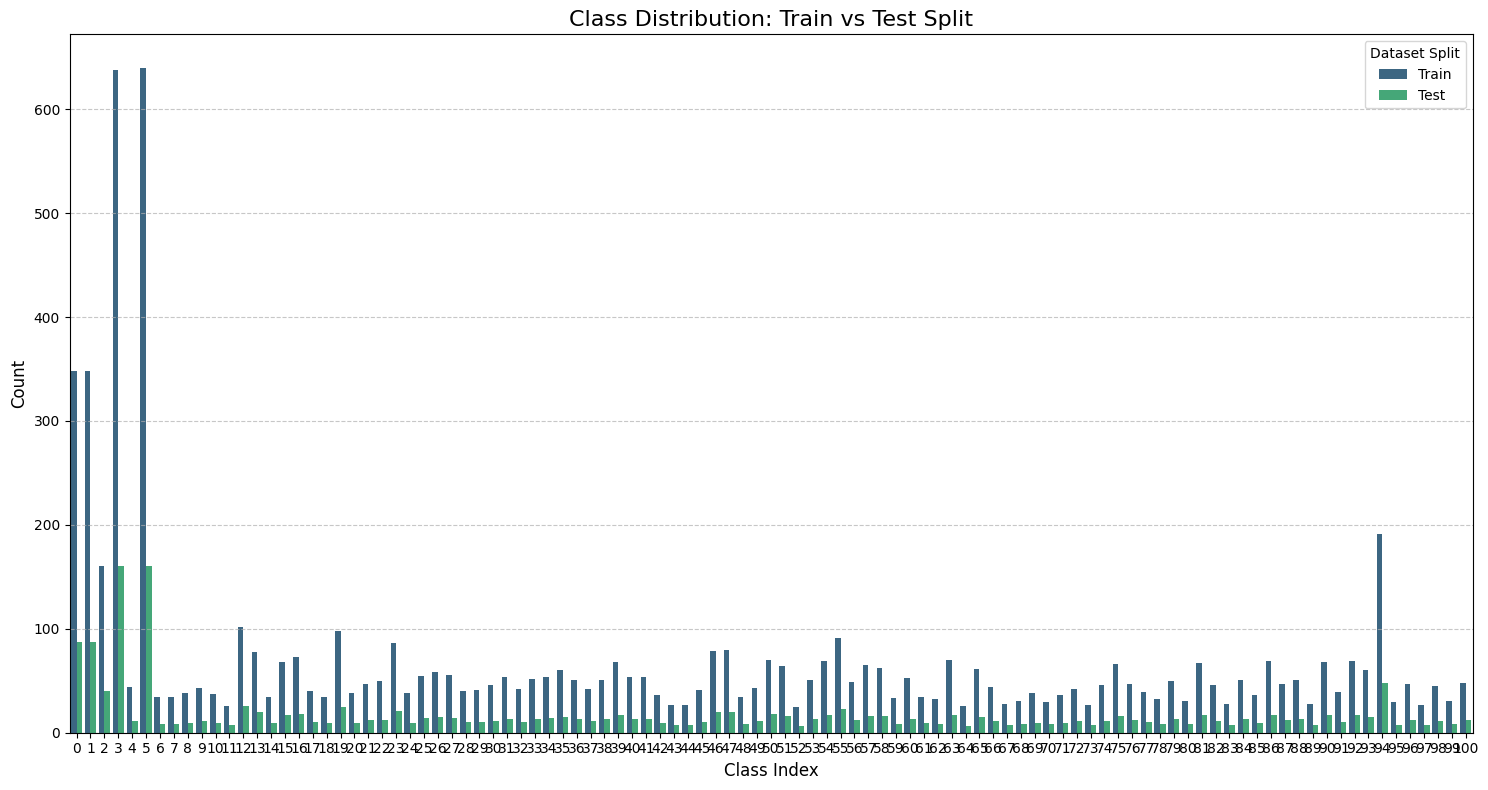

Total Training Samples: 6941
Total Test Samples: 1736
Split Ratio: 0.25


In [52]:
visualize_dataset_distribution(train_ds=nat_images_train, test_ds=nat_images_test)

In [67]:
batch_size = 128# since we are using v5e-1 TPU, have 128 as the best option
nat_train_loader = torch.utils.data.DataLoader(nat_images_train, batch_size=batch_size, shuffle=True)
nat_test_loader = torch.utils.data.DataLoader(nat_images_test, batch_size=batch_size, shuffle=False)

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

def init_weights(m):
    # Check if the sub-module is a Linear layer
    if isinstance(m, nn.Linear):
        # Reach inside the module and grab the 'weight' tensor
        nn.init.xavier_uniform_(m.weight)
        # Often we initialize biases to a small constant or zero
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.01)
            
    # Check if it's a Convolutional layer
    elif isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)
        
class PseudoAlexNet(nn.Module):
    def __init__(self):
        super(PseudoAlexNet, self).__init__()
        # Input: 3 x 300 x 200
        
        # Conv 1
        self.conv1 = nn.Conv2d(3, 96, kernel_size=7, stride=3, padding=3)
        self.bn1 = nn.BatchNorm2d(96)
        
        # Conv 2
        self.conv2 = nn.Conv2d(96, 128, kernel_size=5, stride=2, padding=2)
        self.bn2 = nn.BatchNorm2d(128)
        
        # Conv 3
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        
        # Conv 4
        self.conv4 = nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(384)
        
        # Linear Layers (Flattened size: 384 * 12 * 8 = 36864)
        self.fc1 = nn.Linear(384 * 12 * 8, 256)
        self.bn_fc = nn.BatchNorm1d(256) # 1D for Linear layers
        self.fc2 = nn.Linear(256, 101)

    def forward(self, x):
        # Layer 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        
        # Layer 2 + Pool
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        # Layer 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        
        # Layer 4 + Pool
        x = self.conv4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        # Flatten
        x = x.view(x.size(0), -1) 
        
        # Fully Connected 1
        x = self.fc1(x)
        x = self.bn_fc(x)
        x = F.relu(x)
        
        # Output
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [7]:
#checkpointing logic
import os
from typing import Optional

def save_checkpoint(model, optimizer, epoch, loss, path="/kaggle/working/", file_name: Optional[str]):
    """
    Saves the current state of training per epoch. but willl be practically done per each 10 epoch due to memory contraints.
    """
    state = {
        'epoch': epoch,
        'state_dict': model.state_dict(),     # The actual weights
        'optimizer': optimizer.state_dict(),   # Momentum, learning rates, etc.
        'loss': loss,
    }
    if file_name is None:
        torch.save(state, f"{path}/after_{epoch}_checkpoint.pth")
    else:
        torch.save(state, f"{path}{filename}.pth")
    print(f"Checkpoint saved to {path} at epoch {epoch}")

def load_checkpoint(model, optimizer: Optional[None], path_to_checkpoint ="/kaggle/input/"):
    """
    Loads a saved state and updates the model and optimizer.
    """
    if os.path.exists(f'{path}'):
        checkpoint = torch.load(path)
        model.load_state_dict(checkpoint['state_dict'])
        if optimizer is not None:
            optimizer.load_state_dict(checkpoint['optimizer'])
        epoch = checkpoint['epoch']
        loss = checkpoint['loss']
        print(f"Reverting the model from epoch {epoch} with loss {loss:.4f}")
        return epoch
    else:
        print("No checkpoint found at this path.")
        return 0

SyntaxError: parameter without a default follows parameter with a default (2290817826.py, line 5)

In [70]:
import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.distributed.parallel_loader as pl # For MpDeviceLoader
import torch_xla.runtime as xr # For runtime utilities like world_size
import torch_xla.debug.metrics as met
import time


def mp_mnist_fn(args):
    torch.manual_seed(args.seed)

    # 1. Acquire the XLA device for THIS process.
    device = torch_xla.device()

    # 2. Create the model and move it to the process-specific XLA device
    model = PseudoAlexNet()
    #model.to(torch.bfloat16)
    model.to(device)
    #model.apply(init_weights)
    print(model)

    # 3. Create the optimizer
    optimizer = optim.SGD(model.parameters(), lr=args.learning_rate, momentum=args.momentum)
    loss_fn = nn.NLLLoss()

    # 4. Wrap both DataLoaders with MpDeviceLoader
    mp_train_loader = pl.MpDeviceLoader(args.train_loader, device)
    mp_test_loader = pl.MpDeviceLoader(args.test_loader, device)

    if xm.is_master_ordinal(local=False):
        print(f"Starting distributed training on {xr.world_size()} XLA devices...")

    print(f"Starting training of model in {args.epochs} epochs.")
    start_time = time.time()
    for epoch in range(1, args.epochs + 1):
        epoch_start_time = time.time()

        # --- TRAINING LOOP ---
        model.train()
        for batch_idx, (data, target) in enumerate(mp_train_loader):
            #data, target = data.to(torch.bfloat16), target.to(torch.bfloat16)
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = loss_fn(output, target)
            loss.backward()

            xm.optimizer_step(optimizer)
            
            torch_xla.sync()
            if batch_idx % args.log_interval == 0:
                if xm.is_master_ordinal(local=False):
                    print(f'Train Epoch: {epoch} '
                          f'[{batch_idx * len(data) * xr.world_size()}/{len(args.train_loader.dataset)} '
                          f'({100. * batch_idx / len(args.train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

        # --- EVALUATION LOOP ---
        if xm.is_master_ordinal(local=False) and epoch % 5 == 0:
            model.eval()
            local_correct = 0
            local_total = 0
    
            with torch.no_grad():
                for data, target in mp_test_loader:
                    #data, target = data.to(torch.bfloat16), target.to(torch.bfloat16)
                    data, target = data.to(device), target.to(device)
                    output = model(data)
                    pred = output.argmax(dim=1, keepdim=True)
    
                    local_correct += pred.eq(target.view_as(pred)).sum().item()
                    local_total += target.size(0)
    
            global_correct = xm.mesh_reduce('test_correct', local_correct, sum)
            global_total = xm.mesh_reduce('test_total', local_total, sum)
            accuracy = 100. * global_correct / global_total
            print(f'\n--- Epoch {epoch} Evaluation ---')
            print(f'Test set: Accuracy: {global_correct}/{global_total} ({accuracy:.2f}%)\n')

        # --- CHECKPOINTING (Every 10th Epoch) ---
        if epoch % 10 == 0:
            # We restrict the save function to the master ordinal to prevent file corruption
            # from multiple TPU cores writing to Google Drive simultaneously.
            if xm.is_master_ordinal(local=False):
                # Passing loss.item() from the last training batch of the epoch
                save_checkpoint(model, optimizer, epoch, loss.item())

        epoch_finish_time = time.time()

        print(f"Total time of epoch {epoch} is {epoch_finish_time - epoch_start_time}")

    print(f"Total training time of the model is {time.time() - start_time}")
    if xm.is_master_ordinal(local=False):
        print("Distributed Training and Evaluation finished!")



In [18]:
class Args:
    epochs = 50            # Increased to 50 so you can actually see the checkpointing trigger
    learning_rate = 0.01
    momentum = 0.9
    seed = 317
    log_interval = 3

In [72]:
#args = Args()

#args.train_loader = nat_train_loader
#args.test_loader = nat_test_loader
#mp_mnist_fn(args=args)

PseudoAlexNet(
  (conv1): Conv2d(3, 96, kernel_size=(7, 7), stride=(3, 3), padding=(3, 3))
  (bn1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(96, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=36864, out_features=256, bias=True)
  (bn_fc): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=101, bias=True)
)
Starting distributed training on 1 XLA devices...
Starting training of model in 50 epochs.
Tra

**Here is the fine-tuning part of it.**
1. Loading the model parameters into the model.

In [2]:
import torch
import numpy as np
import torch.utils.data
from torchvision import datasets, transforms

In [43]:
#checkpointing logic
import os
from typing import Optional

def save_checkpoint(model, optimizer, epoch, loss, path="/kaggle/working/", file_name: Optional[str] = None):
    """
    Saves the current state of training per epoch. but willl be practically done per each 10 epoch due to memory contraints.
    """
    state = {
        'epoch': epoch,
        'state_dict': model.state_dict(),     # The actual weights
        'optimizer': optimizer.state_dict(),   # Momentum, learning rates, etc.
        'loss': loss,
    }
    if file_name is None:
        torch.save(state, f"{path}/after_{epoch}_checkpoint.pth")
    else:
        torch.save(state, f"{path}{file_name}.pth")
    print(f"Checkpoint saved to {path} at epoch {epoch}")

def load_checkpoint(model, optimizer: Optional[None], path ="/kaggle/input/"):
    """
    Loads a saved state and updates the model and optimizer.
    """
    if os.path.exists(f'{path}'):
        checkpoint = torch.load(path)
        load_status = model.load_state_dict(checkpoint['state_dict'])
        print(f'The load_status is {load_status}')
        if optimizer is not None:
            optimizer.load_state_dict(checkpoint['optimizer'])
        epoch = checkpoint['epoch']
        loss = checkpoint['loss']
        print(f"Reverting the model from epoch {epoch} with loss {loss:.4f}")
        return epoch
    else:
        print("No checkpoint found at this path.")
        return 0

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

def init_weights(m):
    # Check if the sub-module is a Linear layer
    if isinstance(m, nn.Linear):
        # Reach inside the module and grab the 'weight' tensor
        nn.init.xavier_uniform_(m.weight)
        # Often we initialize biases to a small constant or zero
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.01)
            
    # Check if it's a Convolutional layer
    elif isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)
        
class PseudoAlexNet(nn.Module):
    def __init__(self):
        super(PseudoAlexNet, self).__init__()
        # Input: 3 x 300 x 200
        
        # Conv 1
        self.conv1 = nn.Conv2d(3, 96, kernel_size=7, stride=3, padding=3)
        self.bn1 = nn.BatchNorm2d(96)
        
        # Conv 2
        self.conv2 = nn.Conv2d(96, 128, kernel_size=5, stride=2, padding=2)
        self.bn2 = nn.BatchNorm2d(128)
        
        # Conv 3
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        
        # Conv 4
        self.conv4 = nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(384)
        
        # Linear Layers (Flattened size: 384 * 12 * 8 = 36864)
        self.fc1 = nn.Linear(384 * 12 * 8, 256)
        self.bn_fc = nn.BatchNorm1d(256) # 1D for Linear layers
        self.fc2 = nn.Linear(256, 101)

    def forward(self, x):
        # Layer 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        
        # Layer 2 + Pool
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        # Layer 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        
        # Layer 4 + Pool
        x = self.conv4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2, stride=2)
        
        # Flatten
        x = x.view(x.size(0), -1) 
        
        # Fully Connected 1
        x = self.fc1(x)
        x = self.bn_fc(x)
        x = F.relu(x)
        
        # Output
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [45]:
import torch_xla
checkpoint_path = '/kaggle/input/datasets/nazariyyuchnovskiy/20-checkpoint-batchnorm/after_20_checkpoint (1).pth'
model = PseudoAlexNet()

device = torch_xla.device()
model.to(device)

load_checkpoint(model=model, optimizer=None, path=checkpoint_path)

The load_status is <All keys matched successfully>
Reverting the model from epoch 20 with loss 0.0122


20

2. Now set all the gradients to freeze and unfreeze only the last two layers for training.

In [46]:
def initial_freeze_unfreeze(model):
    for param in model.parameters():
        param.requires_grad = False
    
    for param in model.fc1.parameters():
        param.requires_grad = True
    
    for param in model.bn_fc.parameters():
        param.requires_grad = True


def second_unfreeze(model):
    for param in model.conv4.parameters():
        param.requires_grad = True
        
    for param in model.conv3.parameters():
        param.requires_grad = True


fc_last_in_features = model.fc2.in_features
model.fc1 = nn.Linear(in_features=384*11*8, out_features=fc_last_in_features)
model.fc2 = nn.Linear(in_features=fc_last_in_features, out_features=16) # exactly so much classes are in RVL-CDIP


        
    

3. Upload the dataset of RVL-CDIP

In [9]:
def get_balanced_subset(dataset, n_per_class=100, seed: Optional[int] = None):
    '''
    This function will help us create the training/test data
    '''

    if seed is not None:
        np.random.seed(seed)
    # 1. Group indices by class
    class_indices = dict()
    
    for idx, (_, class_id) in enumerate(dataset.samples):
        if class_id in class_indices:
            class_indices[class_id].append(idx)
        else:
            class_indices[class_id] = [idx]
    
    # 2. Randomly pick n_per_class indices for each class
    selected_indices = []
    for class_id, indices in class_indices.items():
        if len(indices) < n_per_class:
            print(f"Warning: Class {dataset.classes[class_id]} only has {len(indices)} images.")
            # Take all if less than 200, or skip this class
            selected_indices.extend(indices)
        else:
            # Shuffle and pick 200
            np.random.shuffle(indices)
            selected_indices.extend(indices[:n_per_class])
            
    # 3. Create a Subset dataset
    return torch.utils.data.Subset(dataset, selected_indices)

In [10]:
from torch.utils.data import Dataset, Subset
from sklearn.model_selection import train_test_split
import numpy as np

def stratified_dataset_split(dataset: Dataset, train_set_percentage: float, random_state: int = 42):
    """
    Extracts a stratified train and test split from a PyTorch Dataset,
    ensuring exact class proportions are maintained.
    """
    # 1. Safely extract targets regardless of dataset structure
    if hasattr(dataset, 'targets'):
        targets = dataset.targets
    elif hasattr(dataset, 'labels'):
        targets = dataset.labels
    elif hasattr(dataset, 'y'):
        targets = dataset.y
    else:
        targets = [dataset[i][1] for i in range(len(dataset))]

    # 2. Format targets for scikit-learn compatibility
    if torch.is_tensor(targets):
        targets = targets.cpu().numpy()
    elif isinstance(targets, list) and torch.is_tensor(targets[0]):
        targets = [t.item() for t in targets]

    # 3. Generate indices and perform stratified split
    indices = np.arange(len(dataset))
    train_indices, test_indices = train_test_split(
        indices,
        train_size=train_set_percentage,
        stratify=targets,
        random_state=random_state
    )

    # 4. Return the resulting Subsets
    return Subset(dataset, train_indices), Subset(dataset, test_indices)

In [13]:
from torchvision.transforms import v2
data_dir = "/kaggle/input/datasets/uditamin/rvl-cdip-small/data"

target_size = (282,200) # typical documents have the size A4, sqrt(2) this is the most close we got to (300,200) of the Caltech101 dataset
data_transforms = transforms.Compose([
    v2.Resize(target_size), # Forces all images to this size
    transforms.CenterCrop(target_size), # Optional: Ensures no weird stretching
    v2.RGB(),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)
balanced_dataset = get_balanced_subset(full_dataset, n_per_class=250) # theoretically it should have benn 315 since 50 avg per class in Caltech101 * 101 classes / 16 classes in RVL CDIP 

In [14]:
print(len(balanced_dataset))

text_images_train, text_images_test = stratified_dataset_split(dataset=balanced_dataset, train_set_percentage=0.8, random_state=317)

print(f"Total images in train set: {len(text_images_train)}")
print(f"Total images in test set: {len(text_images_test)}")

4000
Total images in train set: 3200
Total images in test set: 800


In [47]:
batch_size = 128# since we are using v5e-1 TPU, have 64 as the best option, including the fact that images are tiff, which are much higher quality than jpg
text_train_loader = torch.utils.data.DataLoader(text_images_train, batch_size=batch_size, shuffle=True)
text_test_loader = torch.utils.data.DataLoader(text_images_test, batch_size=batch_size, shuffle=False)

4. And now the training which is split in two stages, warm-up and drift.

In [51]:
import torch.nn.functional as F
import time
import torch
import torch_xla.core.xla_model as xm
import torch_xla.runtime as xr
import torch_xla

def train_and_eval_epoch(epoch, model, mp_train_loader, mp_test_loader, optimizer, loss_fn, device, args, warmup_epoch: bool = False):
    epoch_start_time = time.time()

    # ==========================================
    # --- TRAINING LOOP ---
    # ==========================================
    model.train()
    local_train_correct = 0
    local_train_total = 0
    local_train_conf = 0.0

    for batch_idx, (data, target) in enumerate(mp_train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()

        xm.optimizer_step(optimizer)
        torch_xla.sync()
        
        # --- CALCULATE METRICS (TPU Local) ---
        # Wrap in no_grad so we don't build a graph for our metric calculations
        with torch.no_grad():
            probs = torch.exp(output) # Assuming output is log_softmax
            preds = probs.argmax(dim=1, keepdim=True)
            
            local_train_correct += preds.eq(target.view_as(preds)).sum().item()
            local_train_total += target.size(0)
            
            max_probs, _ = torch.max(probs, dim=1)
            local_train_conf += max_probs.sum().item()

        # --- LOGGING ---
        if batch_idx % args.log_interval == 0:
            if xm.is_master_ordinal(local=False):
                print(f'Train Epoch: {epoch} '
                      f'[{batch_idx * len(data) * xr.world_size()}/{len(mp_train_loader)} '
                      f'({100. * batch_idx / len(mp_train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

    # --- MESH REDUCE TRAINING METRICS (Cross-Core) ---
    # We must sum the correct predictions and probabilities across all 8 TPU cores
    global_train_correct = xm.mesh_reduce('train_correct', local_train_correct, sum)
    global_train_total = xm.mesh_reduce('train_total', local_train_total, sum)
    global_train_conf = xm.mesh_reduce('train_conf', local_train_conf, sum)

    avg_train_acc = global_train_correct / global_train_total
    avg_train_conf = global_train_conf / global_train_total

    if xm.is_master_ordinal(local=False):
        print(f'--- Epoch {epoch} Training Metrics ---')
        print(f'Accuracy: {global_train_correct}/{global_train_total} ({100. * avg_train_acc:.2f}%) | Confidence: {avg_train_conf:.4f}')

    # ==========================================
    # --- EVALUATION LOOP ---
    # ==========================================
    if xm.is_master_ordinal(local=False) and epoch % 5 == 0:
        model.eval()
        local_correct = 0
        local_total = 0

        with torch.no_grad():
            for data, target in mp_test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1, keepdim=True)

                local_correct += pred.eq(target.view_as(pred)).sum().item()
                local_total += target.size(0)

        global_correct = xm.mesh_reduce('test_correct', local_correct, sum)
        global_total = xm.mesh_reduce('test_total', local_total, sum)
        accuracy = 100. * global_correct / global_total
        
        print(f'\n--- Epoch {epoch} Evaluation ---')
        print(f'Test set: Accuracy: {global_correct}/{global_total} ({accuracy:.2f}%)\n')

    # ==========================================
    # --- CHECKPOINTING & TIMING ---
    # ==========================================
    if epoch % 10 == 0:
        # We restrict the save function to the master ordinal to prevent file corruption
        if xm.is_master_ordinal(local=False):
            if warmup_epoch:
                file_name = f"checkpoint_after_{epoch}_drift"
            else:
                file_name = f"checkpoint_after_{epoch}_warmup"
            save_checkpoint(model, optimizer, epoch, loss.item(), file_name=file_name)

    epoch_finish_time = time.time()

    if xm.is_master_ordinal(local=False):
        print(f"Total time of epoch {epoch} is {epoch_finish_time - epoch_start_time:.2f}s\n")

    # Return the metrics so the Coordinator can use them for early stopping/unfreezing
    return avg_train_acc, avg_train_conf, loss.item()

In [49]:
import torch.optim
import torch_xla.debug.metrics as met
import torch_xla.distributed.parallel_loader as pl

MAX_WARMUP_EPOCHS = 20
MAX_DRIFT_EPOCHS = 30
CONFIDENCE_THRESHOLD = 0.80
ACC_DELTA_THRESHOLD = 0.005
SEED = 317


#defining variables needed for the whole double-stage training cycle and setting up the rest.
torch.manual_seed(SEED)
device = torch_xla.device()
model.to(device)

if xm.is_master_ordinal(local=False):
        print(f"Starting distributed training on {xr.world_size()} XLA devices...")
    
loss_fn = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-5, momentum=0.9)

mp_train_loader = pl.MpDeviceLoader(text_train_loader, device)
mp_test_loader = pl.MpDeviceLoader(text_test_loader, device)

args = Args()

Starting distributed training on 1 XLA devices...


In [50]:
print("=== STAGE 1: Head Warm-up ===")

prev_acc = 0.0
#initial freeze of all layers and unfreeze of the fully connected layers.
print(f"Starting training of the stage 1 in {MAX_WARMUP_EPOCHS} epochs.")
start_warmup_time = time.time()
initial_freeze_unfreeze(model=model)
for epoch in range(1, MAX_WARMUP_EPOCHS + 1):
    print(f"Warm-up Epoch {epoch}/{MAX_WARMUP_EPOCHS}...")
    
    # Run your function
    train_acc, train_conf, loss = train_and_eval_epoch(epoch=epoch, model=model, mp_train_loader=mp_train_loader,
                                                       mp_test_loader=mp_test_loader,optimizer=optimizer, loss_fn=loss_fn,
                                                       device=device, args=args)
    
    # Calculate the change in accuracy
    acc_delta = abs(train_acc - prev_acc)
    
    # THE BREAK CONDITION
    if train_conf >= CONFIDENCE_THRESHOLD and acc_delta <= ACC_DELTA_THRESHOLD:
        print(f"\n>>> THRESHOLDS MET at Epoch {epoch} <<<")
        print(">>> Head is fully calibrated. Breaking warm-up cycle.")
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=loss, file_name="checkpoint_warm_up_complete") 
        break # Exit the warm-up loop early

    if epoch == MAX_WARMUP_EPOCHS:
        save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=loss, file_name="checkpoint_warm_up_complete")       
    prev_acc = train_acc

print(f"Finished stage 1 in {time.time() - start_warmup_time}")

=== STAGE 1: Head Warm-up ===
Starting training of the stage 1 in 20 epochs.
Warm-up Epoch 1/20...
Train Epoch: 1 [0/25 (0%)]	Loss: 2.864128
Train Epoch: 1 [384/25 (12%)]	Loss: 2.891661
Train Epoch: 1 [768/25 (24%)]	Loss: 2.845421
Train Epoch: 1 [1152/25 (36%)]	Loss: 2.765871
Train Epoch: 1 [1536/25 (48%)]	Loss: 2.850782
Train Epoch: 1 [1920/25 (60%)]	Loss: 2.824545
Train Epoch: 1 [2304/25 (72%)]	Loss: 2.840574
Train Epoch: 1 [2688/25 (84%)]	Loss: 2.867070
Train Epoch: 1 [3072/25 (96%)]	Loss: 2.821311
--- Epoch 1 Training Metrics ---
Accuracy: 196/3200 (6.12%) | Confidence: 0.1291
Total time of epoch 1 is 32.76s

Warm-up Epoch 2/20...
Train Epoch: 2 [0/25 (0%)]	Loss: 2.738635
Train Epoch: 2 [384/25 (12%)]	Loss: 2.805494
Train Epoch: 2 [768/25 (24%)]	Loss: 2.814221
Train Epoch: 2 [1152/25 (36%)]	Loss: 2.803579
Train Epoch: 2 [1536/25 (48%)]	Loss: 2.711784
Train Epoch: 2 [1920/25 (60%)]	Loss: 2.831194
Train Epoch: 2 [2304/25 (72%)]	Loss: 2.697514
Train Epoch: 2 [2688/25 (84%)]	Loss: 2.72

In [52]:
#unfreezing two other convolutional layers
second_unfreeze(model=model)
# Drop the learning rate so the newly unfrozen layers don't shatter
for param_group in optimizer.param_groups:
    param_group['lr'] = 1e-5

print("\n=== STAGE 2: Representational Drift ===")

start_drift_time = time.time()
for epoch in range(1, MAX_DRIFT_EPOCHS + 1):
    print(f"Drift Epoch {epoch}/{MAX_DRIFT_EPOCHS}...")
    
    # You can reuse the same training function, or write a new one 
    # if you want to track different metrics during this phase.
    _, _, _ = train_and_eval_epoch(epoch=epoch, model=model, mp_train_loader=mp_train_loader,
                                                       mp_test_loader=mp_test_loader,optimizer=optimizer, loss_fn=loss_fn,
                                                       device=device, args=args)

print(f"Finished stage 2 in {time.time() - start_drift_time}")


=== STAGE 2: Representational Drift ===
Drift Epoch 1/30...
Train Epoch: 1 [0/25 (0%)]	Loss: 1.997504
Train Epoch: 1 [384/25 (12%)]	Loss: 1.985060
Train Epoch: 1 [768/25 (24%)]	Loss: 2.011149
Train Epoch: 1 [1152/25 (36%)]	Loss: 2.103101
Train Epoch: 1 [1536/25 (48%)]	Loss: 1.905970
Train Epoch: 1 [1920/25 (60%)]	Loss: 2.002222
Train Epoch: 1 [2304/25 (72%)]	Loss: 1.959081
Train Epoch: 1 [2688/25 (84%)]	Loss: 1.939719
Train Epoch: 1 [3072/25 (96%)]	Loss: 2.059094
--- Epoch 1 Training Metrics ---
Accuracy: 1495/3200 (46.72%) | Confidence: 0.2219
Total time of epoch 1 is 33.64s

Drift Epoch 2/30...
Train Epoch: 2 [0/25 (0%)]	Loss: 1.934541
Train Epoch: 2 [384/25 (12%)]	Loss: 1.894205
Train Epoch: 2 [768/25 (24%)]	Loss: 2.027763
Train Epoch: 2 [1152/25 (36%)]	Loss: 1.981992
Train Epoch: 2 [1536/25 (48%)]	Loss: 1.951608
Train Epoch: 2 [1920/25 (60%)]	Loss: 1.955609
Train Epoch: 2 [2304/25 (72%)]	Loss: 2.028334
Train Epoch: 2 [2688/25 (84%)]	Loss: 2.074836
Train Epoch: 2 [3072/25 (96%)]	Lo

In [ ]:
!pip instal -q datasets
from datasets import load_dataset

dataset = load_dataset("biglab/webui-val-elements")